# Description
Calculation of the number of passes using real breadcrumbs. Finished on May 18th, 2026. It is the first version it can count by boundary cell. The grid is done by rectangles

In [1]:
%load_ext autoreload
%autoreload 2
%reset -f
%matplotlib widget

In [2]:
from locallib.picarrodb import *
from locallib.query import *
from locallib.box import *
from locallib.query import *

import matplotlib.pyplot as plt
from shapely import wkt
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from shapely.geometry import LineString, Point
from shapely.affinity import rotate
import numpy as np
import pandas as pd
import geopandas as gpd
import warnings
from inc import *
from shapely.ops import polygonize, unary_union

/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/geopandas/_compat.py:154: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.1-CAPI-1.16.0). Conversions between both will be slow.
  set_use_pygeos()


EU1_Conn created successfully
EU2_Conn created successfully
DataHub_Conn created successfully
US_Conn created successfully


# Configuration

In [3]:
tol_deg  = 5
street_length = 10
sampling_distance = 10
dx = 1            # Thickness of each vertical bar
angles = np.arange(0, 190, 10)

# Query the surveys

In [4]:
a = get_reports('Cadent',years = [2026]).execute([EU2_Conn])
report_bc = a.iloc[[700]].copy()
report_bc.db.set_query(query_Segments_byReport(report_table = '#TempReport'))
segments = report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')

l = 0
surveys = segments['SurveyId'].unique()
#survey = segments[segments['SurveyId'] == surveys[l]]
survey = segments
survey['Breadcrumb_wkt'] = survey['Breadcrumb'].apply(wkt.loads)
survey_gdf = gpd.GeoDataFrame(survey, geometry = 'Breadcrumb_wkt', crs = 'EPSG:4326')
utm_crs = survey_gdf.estimate_utm_crs()
survey_gdf = survey_gdf.to_crs(utm_crs)

# Algorithm starts here
## Prepare the surveys

In [5]:
# Compute the union of the survey geometries and simplify the result
survey_union = survey_gdf.unary_union.simplify(2)  # Adjust tolerance 1.0 as needed

# Create a GeoDataFrame from the union
survey_union_gdf = gpd.GeoDataFrame(
    {'geometry': [survey_union]},
    crs=survey_gdf.crs
)

# Make an offset of 10 (buffer by 10 units)
survey_union_offset_gdf = gpd.GeoDataFrame(
    {'geometry': [survey_union.buffer(street_length/2, cap_style=2)]},
    crs=survey_gdf.crs,
    geometry='geometry'
)

In [6]:
# Get the center as the midpoint of the bounds (average of min/max x/y)
minx, miny, maxx, maxy = survey_union_offset_gdf.total_bounds
center = Point((minx + maxx) / 2, (miny + maxy) / 2)
print("Center of the bounds:", center)

# Shift the survey_union_offset_gdf geometry so that the centroid is at (0, 0)
survey_union_offset_gdf['geometry'] = survey_union_offset_gdf.geometry.translate(
    xoff=-center.x, yoff=-center.y
)

Center of the bounds: POINT (565470.42276 5834822.6777)


In [7]:
survey_gdf['geometry'] = survey_gdf.geometry.translate(
    xoff=-center.x, yoff=-center.y
)
survey_gdf.set_geometry('geometry', inplace=True)


In [8]:
survey_gdf

,ReportId,SurveyId,Breadcrumb,Order,Breadcrumb_wkt,geometry
0,E230276B-8E27-134E-36E5-3A1FB05E17E1,7F42F37E-FA00-F2D6-41AA-3A1FA8F359DE,"LINESTRING (-2.0356192 52.65834355, -2.0357484...",74,"LINESTRING (565228.873 5834701.618, 565220.199...","LINESTRING (-241.550 -121.059, -250.224 -126.3..."
1,E230276B-8E27-134E-36E5-3A1FB05E17E1,7F42F37E-FA00-F2D6-41AA-3A1FA8F359DE,"LINESTRING (-2.03824978 52.65793545, -2.037904...",82,"LINESTRING (565051.556 5834653.847, 565074.801...","LINESTRING (-418.867 -168.831, -395.622 -160.9..."
2,E230276B-8E27-134E-36E5-3A1FB05E17E1,7F42F37E-FA00-F2D6-41AA-3A1FA8F359DE,"LINESTRING (-2.03636184 52.65642674, -2.036408...",50,"LINESTRING (565181.494 5834487.737, 565178.303...","LINESTRING (-288.928 -334.940, -292.119 -332.7..."
3,E230276B-8E27-134E-36E5-3A1FB05E17E1,7F42F37E-FA00-F2D6-41AA-3A1FA8F359DE,"LINESTRING (-2.0406504 52.65558979, -2.0410914...",62,"LINESTRING (564892.658 5834390.772, 564862.329...","LINESTRING (-577.765 -431.906, -608.094 -395.0..."
4,E230276B-8E27-134E-36E5-3A1FB05E17E1,7F42F37E-FA00-F2D6-41AA-3A1FA8F359DE,"LINESTRING (-2.03039171 52.6581577, -2.0303096...",8,"LINESTRING (565582.720 5834685.691, 565588.204...","LINESTRING (112.297 -136.987, 117.781 -131.766..."
...,...,...,...,...,...,...
340,E230276B-8E27-134E-36E5-3A1FB05E17E1,26F723B2-F6BD-7850-DFD9-3A1FAE1D1557,"LINESTRING (-2.03776445 52.65695171, -2.037645...",9,"LINESTRING (565085.843 5834544.863, 565093.834...","LINESTRING (-384.580 -277.815, -376.588 -271.2..."
341,E230276B-8E27-134E-36E5-3A1FB05E17E1,26F723B2-F6BD-7850-DFD9-3A1FAE1D1557,"LINESTRING (-2.03521865 52.65735483, -2.034863...",3,"LINESTRING (565257.437 5834592.005, 565281.304...","LINESTRING (-212.986 -230.673, -189.118 -217.4..."
342,E230276B-8E27-134E-36E5-3A1FB05E17E1,26F723B2-F6BD-7850-DFD9-3A1FAE1D1557,"LINESTRING (-2.03539776 52.65907928, -2.035502...",26,"LINESTRING (565242.755 5834783.655, 565235.755...","LINESTRING (-227.668 -39.023, -234.668 -47.565..."
343,E230276B-8E27-134E-36E5-3A1FB05E17E1,26F723B2-F6BD-7850-DFD9-3A1FAE1D1557,"LINESTRING (-2.03234979 52.65904797, -2.032147...",22,"LINESTRING (565448.952 5834782.936, 565462.275...","LINESTRING (-21.471 -39.741, -8.148 -12.996, 4..."


/tmp/ipykernel_1059560/3853611118.py:4: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


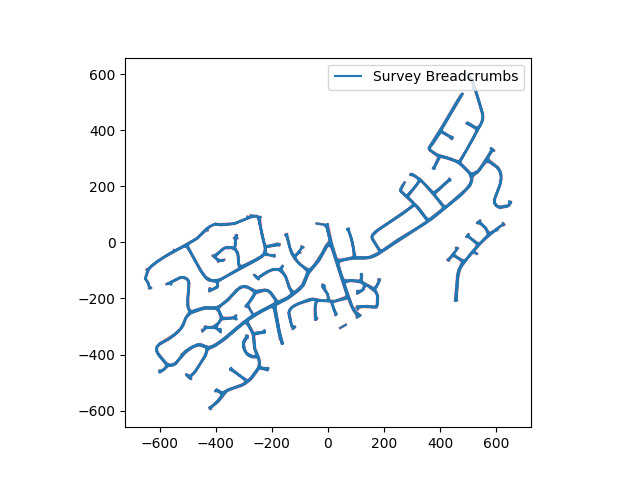

In [9]:
fig,ax = plt.subplots()
survey_gdf.plot(ax=ax, label='Survey Breadcrumbs')
survey_union_offset_gdf.plot(ax=ax, color='red', alpha=0.5, label='Street')
ax.legend()

# Generate the grid

In [10]:
output_gdf = gpd.GeoDataFrame()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for angle in angles:
            #print(f'Processing angle: {angle}')
            # Parameters for evenly spaced thin vertical rectangles (grid "bars")
            bounds = survey_union_offset_gdf.total_bounds
            min_x, min_y, max_x, max_y = map(float, bounds)  # Ensure cast to float
            r_x = np.sqrt(max_x**2 + max_y**2)
            r_y = np.sqrt(min_x**2 + min_y**2)

            # Compute number of columns safely and cast to int
            num_cols = int(np.floor((2*r_x) / sampling_distance)) + 1

            # Compute bar center x-positions
            x_centers = np.linspace(-r_x, r_x, num=num_cols)

            # For each center, form a thin rectangle
            vertical_bars = [
                Polygon([
                    (x - dx/2, min_y),
                    (x + dx/2, min_y),
                    (x + dx/2, max_y),
                    (x - dx/2, max_y)
                ])
                for x in x_centers
            ]

           # Define the vector
            vec = np.array([1,0])
            ortho_vec = np.array([0,1])
            # Define a rotation angle in radians (example: 45 degrees)
            theta = np.deg2rad(angle)
            rotation_matrix = np.array([
                [np.cos(theta), -np.sin(theta)],
                [np.sin(theta), np.cos(theta)]
            ])

            # Rotate the vector by the rotation matrix
            rotated_vec = rotation_matrix @ vec
            ortho_vec = rotation_matrix @ ortho_vec

            # Rotate the grid lines accordingly
            vertical_bars_r = [rotate(bar, angle=angle, origin=(0,0)) for bar in vertical_bars]
            grid_lines_gdf_r = gpd.GeoDataFrame({'geometry': vertical_bars_r}, crs=utm_crs, geometry='geometry')
            grid_lines_gdf_r['grid_idx'] = grid_lines_gdf_r.index

            #Create the intersection of the grid with the survey offset
            intersection_gdf = gpd.overlay(
                grid_lines_gdf_r, 
                survey_union_offset_gdf, 
                how='intersection', 
                keep_geom_type=False
            )
            intersection_gdf = intersection_gdf.explode(index_parts=True)
            intersection_gdf.reset_index(drop=True, inplace=True)
            intersection_gdf.set_geometry('geometry', inplace=True)

            try:
                #Get the bottom points of the intersected rectamgles
                intersection_gdf['bottom_points'] = intersection_gdf['geometry'].apply(get_bottom_points)
            except Exception as e:
                print(f'No bottom points for angle {angle}')
                print(intersection_gdf['geometry'])
                print(e)

            # Get the unit vector along the [1,0] direction or the rotated version
            intersection_gdf['unit_vector'] = intersection_gdf['bottom_points'].apply(safe_unit_vector)

            # Get teh angle between the unit vector and the rotated vector
            intersection_gdf['angle'] = intersection_gdf['unit_vector'].apply(lambda vec: angle_between_vectors(vec, rotated_vec=rotated_vec))

            # Get only those lines which are aligned with the rotated vector
            right_angles = intersection_gdf[np.isclose(intersection_gdf['angle'], 0, atol=tol_deg)]
            if len(right_angles) > 0:
                #print('There is a right angle')
                #Get the cell boundaries
                right_angles['cell_boundary'] = right_angles.apply(lambda row: get_line_from_angle(row, ortho_vec), axis=1)

                #Rename the grid_idx to include the angle
                right_angles['grid_idx'] = right_angles.apply(lambda row: f"{row['grid_idx']}_{angle}", axis=1)
                right_angles.reset_index(drop=True)
                output_gdf = pd.concat([output_gdf, right_angles])

# Remove entries whose cell_boundary length > 1 std above the mean
lengths = output_gdf.cell_boundary.length
mean_length = lengths.mean()
std_length = lengths.std()
filtered_output_gdf = output_gdf[lengths <= (mean_length + std_length/2)]


#Remove all the intersecting 
#Create the cells
geom = survey_union_offset_gdf.iloc[0].geometry

# All grid lines as one noded multiline (tweak attribute if your geometry column differs)
lines = [getattr(row, "cell_boundary") for row in filtered_output_gdf.itertuples()]
splitters = unary_union(lines)
network = unary_union([geom.boundary, splitters])
cell_polys = [
    poly
    for poly in polygonize(network)
    if geom.contains(poly.representative_point())
]
print(len(lines), "splitters ->", len(cell_polys), "cells")
cell_gdf = gpd.GeoDataFrame({'geometry': cell_polys}, crs=survey_union_offset_gdf.crs)
cell_gdf = cell_gdf.reset_index().rename(columns={'index': 'cell_idx'})


802 splitters -> 862 cells


In [26]:
intersection_gdf

,grid_idx,geometry,bottom_points,unit_vector,angle
0,24,"POLYGON ((647.752 150.068, 648.752 149.835, 64...","[(648.7519051378367, 128.21561047062974), (647...","[-0.8441928040649992, -0.5360396529780924]",-32.414446
1,25,"POLYGON ((637.701 135.763, 638.701 135.908, 63...","[(638.7014880039167, 123.20798404527935), (637...","[-0.9652356497436393, -0.26138121673902764]",-15.152034
2,26,"POLYGON ((627.651 72.522, 627.900 72.240, 628....","[(628.6510708699968, 57.61802554351824), (627....","[-0.9432478137453528, -0.33208968948856626]",-19.395660
3,26,"POLYGON ((627.651 134.302, 628.651 134.448, 62...","[(628.6510708699968, 121.08314360169807), (627...","[-0.9824601896048459, -0.18647245330506643]",-10.746992
4,27,"POLYGON ((617.601 65.810, 618.288 66.356, 618....","[(618.6006537360768, 53.83512737730907), (617....","[-0.783155461259246, -0.6218259591717104]",-38.449599
...,...,...,...,...,...
588,151,"POLYGON ((-628.651 -157.981, -628.233 -158.213...","[(-628.5213600000134, -166.87038999982178), (-...","[-0.9047532481401274, -0.4259360984700511]",-25.209930
589,151,"POLYGON ((-628.651 -76.817, -628.210 -76.455, ...","[(-627.9341899999417, -90.77374999970198), (-6...","[-0.681150336194072, -0.7321435784753579]",-47.066400
590,152,"POLYGON ((-638.701 -139.647, -637.701 -141.295...","[(-638.5934099999722, -164.11897999979556), (-...","[-0.8518233577351675, 0.5238291393353225]",31.589455
591,152,"POLYGON ((-638.701 -85.467, -637.701 -84.633, ...","[(-637.7014880039168, -105.36456941683595), (-...","[-0.39246041069586973, -0.9197688981675938]",-66.892320


## Count the intersections by cell

In [11]:
# For each cell, create an inner offset to prevent bad counts
cell_offset_gdf = gpd.GeoDataFrame(geometry=cell_gdf.buffer(-0.1).explode(index_parts=False), crs=cell_gdf.crs)
cell_boundaries_gdf = gpd.GeoDataFrame(geometry=cell_offset_gdf.boundary.explode(), crs=cell_offset_gdf.crs)

/tmp/ipykernel_1059560/1053509735.py:3: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  cell_boundaries_gdf = gpd.GeoDataFrame(geometry=cell_offset_gdf.boundary.explode(), crs=cell_offset_gdf.crs)


In [12]:

#For each cell, partition the polygon into segments along its boundary lines using exterior coordinates. This will help us to get the nummber of boundaries
segment_list = []
for poly in cell_offset_gdf.geometry:
    coords = list(poly.exterior.coords)
    for i in range(len(coords) - 1):
        seg = LineString([coords[i], coords[i+1]])
        segment_list.append(seg)

partitioned_gdf = gpd.GeoDataFrame(geometry=segment_list, crs=cell_offset_gdf.crs)

#Get the intersections of the surveys with the boundaries
points = gpd.GeoDataFrame(
    gpd.overlay(survey_gdf, cell_boundaries_gdf, how='intersection', keep_geom_type=False).explode(),
    crs=survey_gdf.crs
)
points = points.set_geometry('geometry')
points_buffer = gpd.GeoDataFrame(geometry=points.buffer(0.05), crs=points.crs)

#Get the boundaries that intersect with the survey
points_buffer.reset_index(drop=True, inplace=True)
boundaries = gpd.sjoin(points_buffer, partitioned_gdf, how='right', predicate='intersects')


/tmp/ipykernel_1059560/336621587.py:13: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  gpd.overlay(survey_gdf, cell_boundaries_gdf, how='intersection', keep_geom_type=False).explode(),


In [13]:
#Get the boundaries that intersect with the survey
points_buffer.reset_index(drop=True, inplace=True)
boundaries = gpd.sjoin(points_buffer, partitioned_gdf, how='right', predicate='intersects')
# Fix: Only cast to int if value is finite (not NA/inf) to avoid IntCastingNaNError
if boundaries['index_left'].notnull().all():
    boundaries['index_left'] = boundaries['index_left'].astype(int)
else:
    # Fill NA with a placeholder (e.g., -1) before casting, or just keep NA if that's acceptable
    boundaries['index_left'] = boundaries['index_left'].fillna(-1).astype(int)
    # Drop rows where index_left == -1
boundaries = boundaries[boundaries['index_left'] != -1]
boundaries.rename(columns={'index_left': 'points_idx'}, inplace=True)
# Get unique geometries from 'boundaries' and put in a GeoDataFrame
unique_geoms = boundaries['geometry'].unique()
unique_gdf = gpd.GeoDataFrame(geometry=list(unique_geoms), crs=boundaries.crs)
unique_gdf.reset_index(drop=True, inplace=True)
joined_gdf_unique = gpd.sjoin(unique_gdf, cell_gdf, how='right', predicate='intersects')
boundary_counts = joined_gdf_unique.groupby('cell_idx').size().reset_index(name='boundaries')

# Get the number of intersections per cell
joined_gdf = gpd.sjoin(points, cell_gdf, how='left', predicate='intersects')
# Get intersection counts by cell
intersection_counts = joined_gdf.groupby('cell_idx').size().reset_index(name='intersections')
intersection_boundaties = intersection_counts.merge(boundary_counts, left_on='cell_idx', right_on='cell_idx', how='left')

#Get the output
cell_summary = cell_gdf.merge(intersection_boundaties, left_on='cell_idx', right_on='cell_idx', how='left')
cell_summary['passes'] = cell_summary['intersections'] / cell_summary['boundaries']

/tmp/ipykernel_1059560/575504383.py:4: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axa.legend()


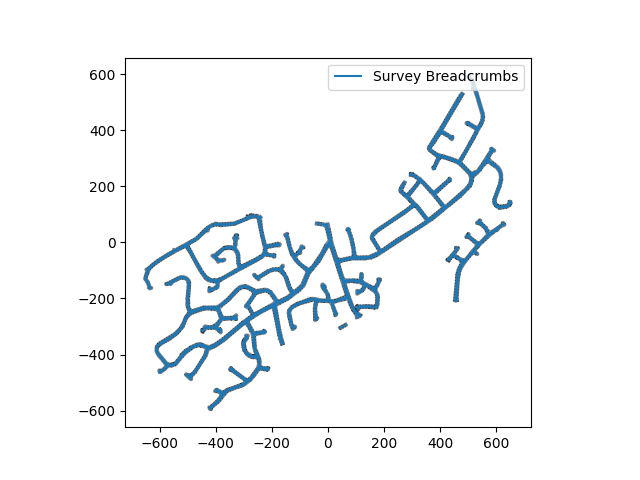

In [14]:
fig,axa = plt.subplots()
cell_gdf.plot(edgecolor='black', facecolor='none', alpha=0.5, ax=axa, label='Grid Cells')
survey_gdf.plot(ax=axa, label='Survey Breadcrumbs')
axa.legend()

In [15]:
# Use geopandas's dissolve to aggregate geometries by the 'passes' column
# This will produce a GeoDataFrame with one row per unique 'passes' value, with multipolygons where appropriate.

# Create a new GeoDataFrame with necessary columns
cell_info_nonan = cell_summary.dropna(subset=['passes']).copy()

dissolved = cell_info_nonan.dissolve(by='passes')

# Ensure the dissolved result is a GeoDataFrame indexed by 'passes'
aggregated_cells_by_pass_gdf = dissolved.reset_index()[['passes', 'geometry']]

/tmp/ipykernel_1059560/1960337944.py:7: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


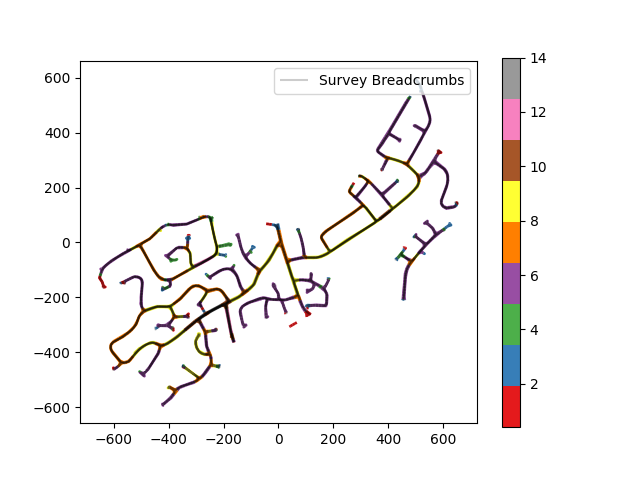

In [16]:
fig, ax = plt.subplots()
plot = cell_summary.plot(column='passes', cmap='Set1', ax=ax, legend=True, label='Number of passes')
survey_gdf.plot(ax=ax, label='Survey Breadcrumbs', color='black', alpha=0.2)
# Set title for colorbar
if plot.get_legend() is not None and hasattr(plot.get_legend(), 'set_title'):
    plot.get_legend().set_title('number of passes')
ax.legend()

In [17]:
aggregated_cells_by_pass_gdf['geometry'] = aggregated_cells_by_pass_gdf.translate(xoff=center.x, yoff=center.y)

In [18]:
survey_4326 = survey_gdf.copy()

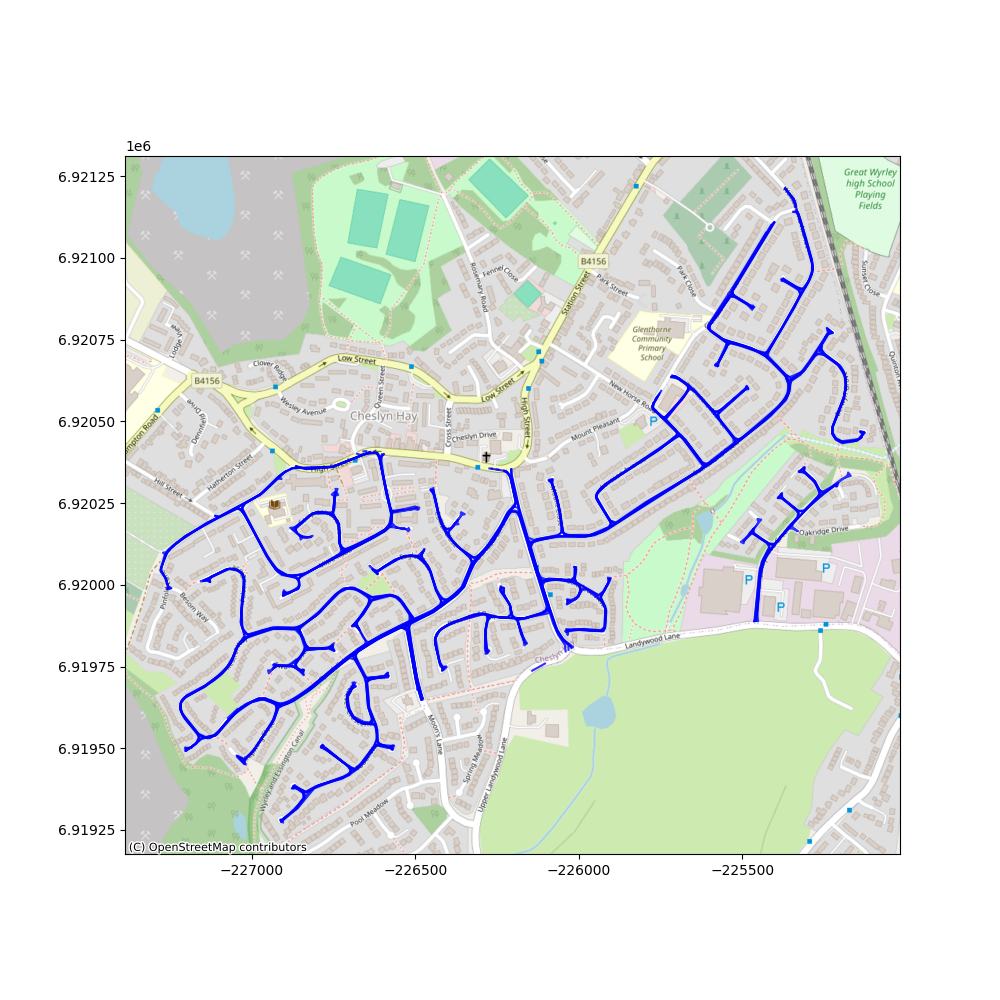

In [19]:
import contextily as ctx

# Project to Web Mercator for plotting with basemap
survey_webmerc = survey_4326.set_geometry('Breadcrumb_wkt').to_crs('EPSG:3857')
ax = survey_webmerc.plot(figsize=(10, 10), alpha=0.8, color='blue')
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


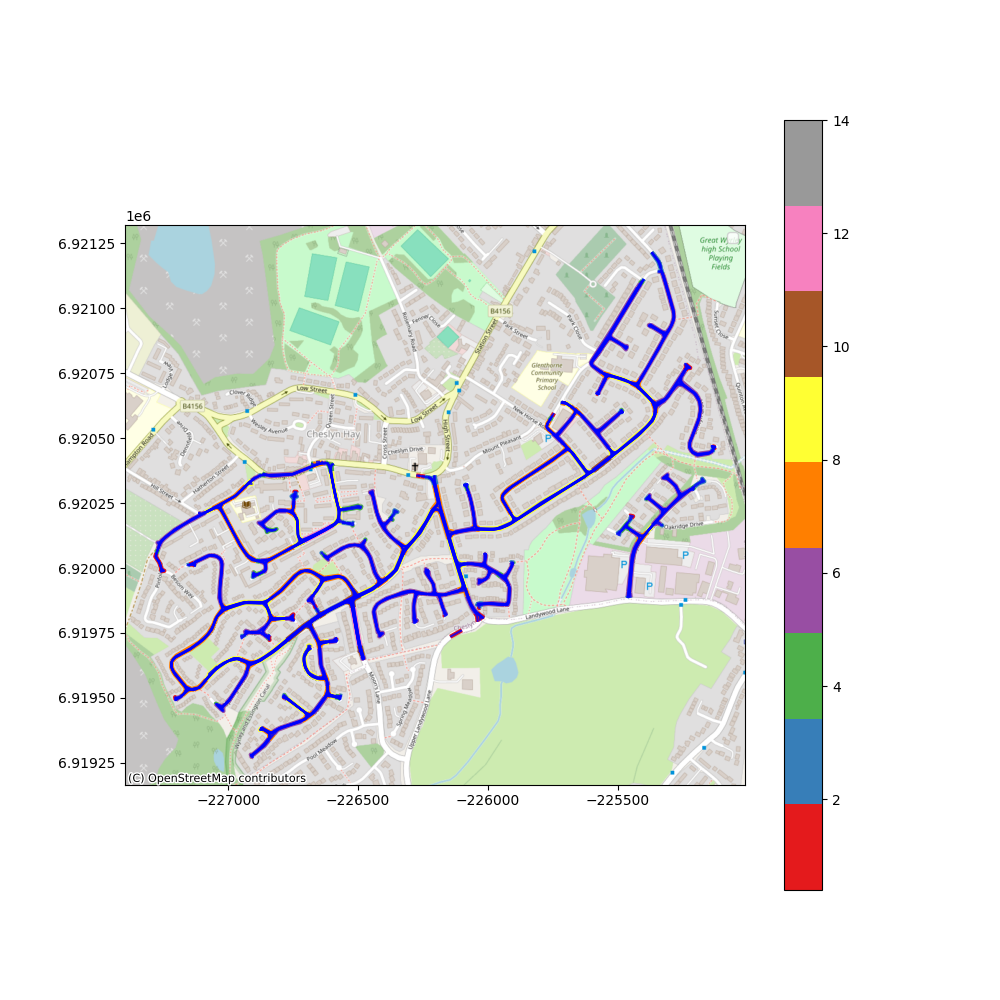

In [20]:
agg = aggregated_cells_by_pass_gdf.to_crs('EPSG:3857')
import contextily as ctx

ax = survey_webmerc.plot(figsize=(10, 10), alpha=0.8, color='blue')
ax = agg.plot(ax = ax, figsize=(10, 10), column='passes', cmap='Set1', legend=True)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.legend()

In [21]:
cell_summary['passes'].value_counts()

passes
6.000000     310
7.000000     104
8.000000     103
9.000000      53
4.000000      26
2.000000      25
5.000000      20
11.000000     17
1.000000      16
10.000000     14
6.666667      12
7.333333      12
3.000000       9
14.000000      7
5.333333       6
4.666667       5
7.500000       4
2.666667       4
4.500000       3
6.500000       3
3.333333       3
1.500000       3
5.500000       2
0.857143       2
1.333333       2
0.400000       1
4.333333       1
0.500000       1
0.428571       1
8.500000       1
1.142857       1
0.888889       1
6.333333       1
0.571429       1
1.600000       1
9.333333       1
0.923077       1
0.909091       1
8.666667       1
Name: count, dtype: int64